In [1]:
import geopandas as gpd
import sys
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
from pathlib import Path
path = Path().cwd().parent / "src" #to add the src directory to the path regognized by Python
sys.path.append(str(path))
import methods_two_point_correlation as mtpc
import methods_epidemics as mepi
import save_load_pickle as slp
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.spatial import distance
import matplotlib.pyplot as plt
import sklearn.cluster as sk
import sys
from sklearn.metrics import silhouette_score
from shapely.geometry import Polygon,Point
from scipy.stats import entropy
import networkx as nx
import EoN
from scipy.stats import ttest_ind
from CLASS_SIR_model import *

# Parameters

In [3]:
#set paths
path = Path().cwd().parent
sys.path.append(str(path))
data_dir = path/"data/cities"
map_dir = path/"data/map"
data_city = data_dir / "cities"
plot_dir = path/"out/plot_fitted_parameters/"

In [4]:
def run_epidemics(mobility_matrix,population,tau,gamma,proportion,number_infected,epsilon):
    l_t = np.linspace(time_span[0], time_span[1], time_step)
    mobility_matrix = mobility_matrix/epsilon
    for i in range(len(mobility_matrix)):
        mobility_matrix[i][i] = 0.5
    Model = Mobility_Matrix_Model  # The model
    parameter = {}
    parameter["tau"] = tau
    parameter["gamma"] = gamma
    parameter["mobility_matrix"] = mobility_matrix
    parameter["population"] = population
    Y0 = mepi.initial_configuration(population,proportion,number_infected)
    epidemics = Metapopulation(Y0, parameter, Model)
    epidemics.run_model(time_span, l_t)
    return epidemics

def run_epidemics_from_path(path,population,tau,gamma,proportion,number_infected,epsilon):
    dico_data = slp.load_results(path)
    mobility_matrix = dico_data["mobility"]
    l_t = np.linspace(time_span[0], time_span[1], time_step)
    mobility_matrix = mobility_matrix/epsilon
    for i in range(len(mobility_matrix)):
        mobility_matrix[i][i] = 0.5
    Model = Mobility_Matrix_Model  # The model
    parameter = {}
    parameter["tau"] = tau
    parameter["gamma"] = gamma
    parameter["mobility_matrix"] = mobility_matrix
    parameter["population"] = population
    Y0 = mepi.initial_configuration(population,proportion,number_infected)
    epidemics = Metapopulation(Y0, parameter, Model)
    epidemics.run_model(time_span, l_t)
    l_R =[]
    for i in range(len(mobility_matrix)):
        l_R.append(epidemics.get_variables("Rh",i)[-1])
    return np.sum(l_R)
    
from itertools import repeat
def wrapper(args):
    return run_epidemics_from_path(*args)
    


POP = None

def init_worker(pop):
    global POP
    POP = pop


def worker(args):
    file, tau, gamma, proportion, number_infected, epsilon = args
    return run_epidemics_from_path(
        file,
        POP,
        tau,
        gamma,
        proportion,
        number_infected,
        epsilon
    )

def run_parallel(path, population, tau, gamma, proportion, number_infected, epsilon):

    files = list(path.iterdir())

    args = zip(
        files,
        repeat(tau),
        repeat(gamma),
        repeat(proportion),
        repeat(number_infected),
        repeat(epsilon)
    )

    with Pool(10, initializer=init_worker, initargs=(population,)) as pool:
        result = list(pool.imap_unordered(worker, args, chunksize=5))

    return result

def distribution_recovered(path,population,tau,gamma,proportion,number_infected,epsilon):
    files = list(path.iterdir())
    files = files[0:10]
    args = zip(files,#,repeat(population),
               repeat(tau),
               repeat(gamma),
               repeat(proportion),
               repeat(number_infected),
               repeat(epsilon))
    #args = [[list_file[i],population,tau,gamma,proportion,number_infected,epsilon] for i in range(len(list_file))] #
    with Pool(10, initializer=init_worker, initargs=(population,)) as pool:
        #result = pool.starmap(run_epidemics_from_path,args,chunksize=20)
        result = list(pool.imap_unordered(worker, args,chunksize=5))
    return result

In [5]:
name = "Belgium" #name of country
load_data =  Path.cwd().parent /Path(f"out/mobility_matrix/{name}/network_data.dat")
dico_data = slp.load_results(load_data)
mobility_matrix = dico_data["mobility"]
#mobility_matrix = np.zeros_like(mobility_matrix)
gdf_projected = dico_data["gdf"]
population = [1000 for i in range(len(mobility_matrix))]

In [35]:
820*10*0.01

82.0

In [36]:
time_step = 100
time_span = [0,50]
tau = 1.5
epsilon = 100
gamma = 1
proportion = 1
number_infected = 1
print(tau/gamma)

1.5


In [37]:
%time epidemics = run_epidemics(mobility_matrix,population,tau,gamma,proportion,number_infected,epsilon)

One run is done
CPU times: user 1min 16s, sys: 0 ns, total: 1min 16s
Wall time: 1min 16s


In [38]:
l_R = []
for i in range(len(mobility_matrix)):
    l_R.append(epidemics.get_variables("Rh",i)[-1])
print("sum people infected ", np.sum(l_R))

sum people infected  501379.86822446703


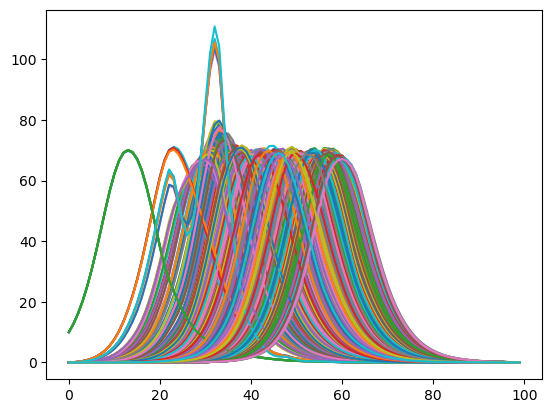

In [44]:
for i in range(800):
    plt.plot(epidemics.get_variables("Ih",i))

In [31]:
load_data =  Path.cwd().parent /Path(f"out/mobility_matrix/{name}/random/network_random1.dat")
dico_data = slp.load_results(load_data)
mobility_random = dico_data["mobility"]
gdf_projected_projected = dico_data["gdf"]

In [43]:
path = Path.cwd().parent /Path(f"out/mobility_matrix/{name}/random")
%time distribution_random = distribution_recovered(path,population,tau,gamma,proportion,number_infected,epsilon)

One run is done
One run is done
One run is done
One run is done
One run is done
One run is done
One run is done
One run is done
One run is done
One run is done
CPU times: user 58.7 ms, sys: 120 ms, total: 179 ms
Wall time: 7min 42s


In [44]:
np.mean(distribution_random)

498880.4459824522

In [45]:
(501379.86822446703-np.mean(distribution_random))/np.std(distribution_random,ddof=1)

0.9580199673847413

In [86]:
epidemics_random = run_epidemics(mobility_random,population,tau,gamma,proportion,number_infected,epsilon)

time: 0.0
time: 1.0172191981225402e-06
time: 2.0344383962450803e-05
time: 3.0516575943676205e-05
time: 8.137753584980321e-05
time: 9.041948427755912e-05
time: 0.00010172191981225402
time: 0.00010172191981225402
time: 0.0003051657594367621
time: 0.00040688767924901607
time: 0.0009154972783102862
time: 0.0010059167625878452
time: 0.0011189411179347943
time: 0.0011189411179347943
time: 0.0031533795141798753
time: 0.004170598712302415
time: 0.009256694702915118
time: 0.010160889545690707
time: 0.011291133099160197
time: 0.011291133099160197
time: 0.031635517061611
time: 0.041807709042836406
time: 0.09266866894896343
time: 0.10171061737671934
time: 0.11301305291141424
time: 0.11301305291141424
time: 0.3149191941019645
time: 0.41587226469723965
time: 0.9206376176736154
time: 1.010373680424971
time: 1.1225437588641656
time: 1.1225437588641656
time: 1.5479458712759953
time: 1.7606469274819103
time: 2.8241522085114847
time: 3.0132198140278534
time: 3.2495543209233144
time: 3.2495543209233144
ti

In [82]:
load_data =  Path.cwd().parent /Path(f"out/mobility_matrix/{name}/generated/network_generated1.dat")
dico_data = slp.load_results(load_data)
mobility_generated = dico_data["mobility"]
gdf_generated = dico_data["gdf"]

In [83]:
l_R = []
for i in range(len(mobility_matrix)):
    l_R.append(epidemics_random.get_variables("Rh",i)[-1])
print("sum people infected ", np.sum(l_R))

sum people infected  495135.5204544838


In [46]:
path = Path.cwd().parent /Path(f"out/mobility_matrix/{name}/generated")
%time distribution_generated = distribution_recovered(path,population,tau,gamma,proportion,number_infected,epsilon)

One run is done
One run is done
One run is done
One run is done
One run is done
One run is done
One run is done
One run is done
One run is done
One run is done
CPU times: user 62.5 ms, sys: 124 ms, total: 186 ms
Wall time: 7min 59s


In [84]:
epidemics_generated = run_epidemics(mobility_generated,population,tau,gamma,proportion,number_infected,epsilon)

time: 0.0
time: 1.0172388600909319e-06
time: 2.034477720181864e-05
time: 3.0517165802727955e-05
time: 8.137910880727456e-05
time: 9.042123200808282e-05
time: 0.00010172388600909319
time: 0.00010172388600909319
time: 0.00030517165802727955
time: 0.00040689554403637275
time: 0.0009155149740818387
time: 0.0010059362060899214
time: 0.001118962746100025
time: 0.001118962746100025
time: 0.0031534404662818885
time: 0.00417067932637282
time: 0.00925687362682748
time: 0.010161085946908307
time: 0.011291351347009343
time: 0.011291351347009343
time: 0.03163612854882798
time: 0.041808517149737295
time: 0.0926704601542839
time: 0.10171258335509217
time: 0.11301523735610253
time: 0.11301523735610253
time: 0.31594418931167034
time: 0.4174086652894542
time: 0.9247310451783738
time: 1.0149216904919593
time: 1.1276599971339416
time: 1.1276599971339416
time: 1.5615378845398595
time: 1.7784768282428187
time: 2.8631715467576138
time: 3.056006163382466
time: 3.2970494341635317
time: 3.2970494341635317
time:

In [47]:
(501379.86822446703-np.mean(distribution_generated))/np.std(distribution_generated,ddof=1)

0.4729502456547351

In [49]:
np.std(distribution_distributed,ddof=1)

2608.945874936106

In [62]:
distribution_generated

[501375.4513199607,
 501349.9909576103,
 496372.64339468506,
 501403.744560273,
 501417.0884498744,
 501381.2192232872,
 501360.2523018747,
 501412.8921762367,
 501361.22040824103,
 496406.81341736356]

In [53]:
from scipy.stats import normaltest

In [57]:
np.mean(distribution_generated)-np.median(distribution_generated)

-984.2042431602022

In [12]:
plt.boxplot([501379.86822446703,distribution_random,distribution_generated])

NameError: name 'distribution_random' is not defined

In [85]:
l_R = []
for i in range(len(mobility_matrix)):
    l_R.append(epidemics_generated.get_variables("Rh",i)[-1])
print("sum people infected ", np.sum(l_R))

sum people infected  496022.46651376074


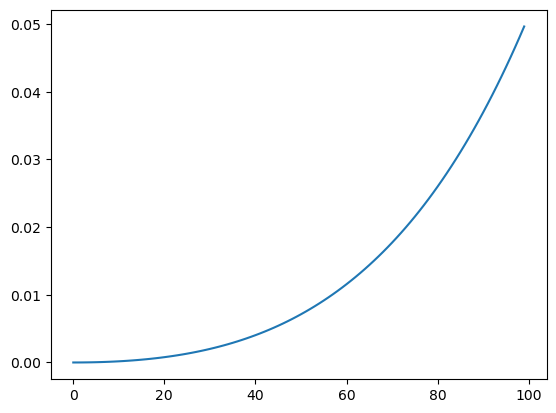

In [31]:
plt.plot(epidemics_generated.get_variables("Rh",10))

In [52]:
494449-495757

-1308

# Check structural properties of the networks generated compared to the data

In [2]:
import nx_parallel as nxp

In [6]:
G_data = nx.DiGraph(mobility_matrix)

819.9999999999999

In [11]:
%time G_lol = nx.clustering(G_data,weight="weight")

AttributeError: module 'networkx' has no attribute 'clusterinf'

In [45]:
s= []
for i in range(len(mobility_matrix)):
    s.append(np.sum(mobility_.T[i]))

In [10]:
lol = nxp.betweenness_centrality(G_data)

TypeError: _rescale() got an unexpected keyword argument 'k'

In [46]:
np.median(s)

0.9829816952253014

In [8]:
average_cluster = nxp.average_clustering(G_data,weight="weight")

AttributeError: module 'nx_parallel' has no attribute 'average_clustering'

In [ ]:
np.sum(mobility_matrix)

# Create the branching rule i.e. the radiation model

In [28]:
sum_distance_random/sum_distance_data

0.9623448353684091

In [29]:
sum_distance_generated/sum_distance_data

0.8943410058023599

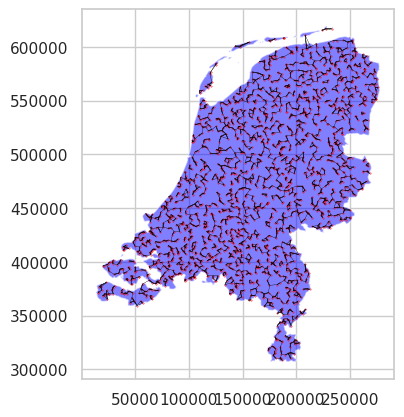

In [37]:
def display_map_mobility(gdf,gdf_edge,mobility_matrix,position,threshold):
    mask = (mobility_matrix >=threshold)
    width =  np.where(mask,mobility_matrix,0)
    width = np.array([width[i] for i in range(len(width))])
    fig,ax = plt.subplots()
    #squares_gdf.plot(ax=ax)
    gdf_edge.plot(ax=ax,color="blue",alpha=0.5)
    gdf.plot(ax=ax,color="red",markersize=0.1)
    for i in range(len(position)):
     for j in range(len(position)):
         if i != j and width[i,j] !=0 and width[i,j] > width[j,i]:
            point1 = [position[i][0],position[i][1]]
            point2 = [position[j][0]-position[i][0],position[j][1]-position[i][1]]
            ax.arrow(point1[0], point1[1],point2[0],point2[1],linestyle="-",linewidth= width[i,j] ,head_width=0.01,head_length=0.02,length_includes_head=True,edgecolor='black',alpha=0.75)
    plt.show()
    
threshold = 0.1
display_map_mobility(gdf_projected_random,gdf_edge,mobility_random,coord_random,threshold)

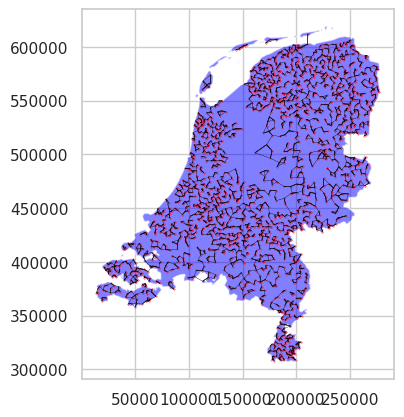

In [38]:
display_map_mobility(gdf_projected,gdf_edge,mobility_data,coord_data,threshold)

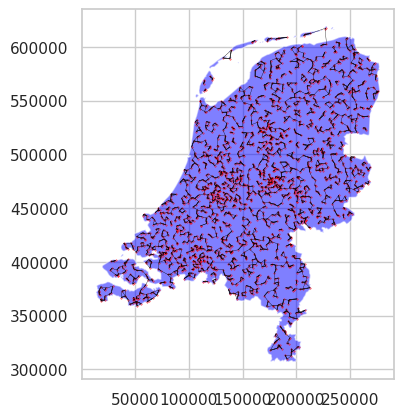

In [39]:
display_map_mobility(gdf_generated,gdf_edge,mobility_generated,coord_generated,threshold)